### section A

#### 1. Why is text considered unstructured data compared to tabular data?

- Tabular data is structured because it's organized into predefined rows and columns, where each cell holds a specific, typed value (e.g., price, rating, date). The schema is fixed — you always know where to look for a given piece of information.

#### Text is unstructured because:

- It has no fixed schema — a review can be 3 words or 3,000 words
- Meaning is implicit — the word "terrible" carries sentiment, but a machine doesn't inherently know that
- Position is not meaningful — unlike column 4 always being "price," the 4th word in a review tells you nothing predictable
- It requires parsing and transformation (tokenization, embeddings, etc.) before any numerical computation can be done on it

#### 2. What is a corpus in NLP terminology?

- A corpus (plural: corpora) is a large, structured collection of text used as the dataset for NLP tasks.

#### In your Amazon Reviews example specifically:

- Corpus  : The entire collection of all Amazon reviews
- Document : One individual review
- Vocabulary : The set of all unique words across the entire corpus
- Token : A single word or unit extracted from a document

- So when you "count unique words across all reviews," you are measuring the vocabulary size of the corpus — often written as |V|, where V is the vocabulary set.

#### 3. What do the most frequent words tell you about usefulness for sentiment analysis?

- The fact that words like 'the', 'a', and 'is' dominate the list tells you they are essentially useless for sentiment analysis. These are called stop words — extremely common function words that carry no emotional or opinion-based meaning.

#### 4. Stages of a Standard NLP Pipeline (in order)

- A standard NLP pipeline includes the following stages in order: data collection, text cleaning/preprocessing, tokenization, stopword removal, stemming or lemmatization, feature extraction/vectorization, model building, evaluation, and deployment.

#### 5. At which stage are URLs, emojis, and symbols handled?

- URLs, emojis, and symbols are handled during the text cleaning or preprocessing stage of the NLP pipeline.

### section B

#### 1. Implement a custom regex-based tokenizer to isolate technical specifications and currency symbols from raw text

In [5]:
import bz2
import pandas as pd

data = []

with bz2.open('test.ft.txt', 'rt', encoding='utf-8') as file:
    for line in file:
        parts = line.split(' ', 1)

        label = parts[0]
        text = parts[1] if len(parts) > 1 else ""

        data.append([label, text])

df = pd.DataFrame(data, columns=['label', 'text'])

df.head()

OSError: Invalid data stream

In [15]:
import bz2
import pandas as pd 

data = []

with bz2.open('test.ft.txt.bz2', 'rt', encoding='utf-8') as file:
    for line in file:
        parts = line.split(' ', 1)

        label = parts[0]
        review = parts[1] if len(parts) > 1 else ""

        data.append([label, review])

print(data[:5])
df = pd.DataFrame(data)


[['__label__2', 'Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I\'m in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life\'s hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"\n'], ['__label__2', "One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's 

In [16]:
df

,0,1
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...
...,...,...
399995,__label__1,Unbelievable- In a Bad Way: We bought this Tho...
399996,__label__1,"Almost Great, Until it Broke...: My son reciev..."
399997,__label__1,Disappointed !!!: I bought this toy for my son...
399998,__label__2,Classic Jessica Mitford: This is a compilation...


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

texts = df[1]

tokenizer = Tokenizer(num_words=5000)       #Only top 5000 most frequent words are used
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

In [21]:
texts

0         Great CD: My lovely Pat has one of the GREAT v...
1         One of the best game music soundtracks - for a...
2         Batteries died within a year ...: I bought thi...
3         works fine, but Maha Energy is better: Check o...
4         Great for the non-audiophile: Reviewed quite a...
                                ...                        
399995    Unbelievable- In a Bad Way: We bought this Tho...
399996    Almost Great, Until it Broke...: My son reciev...
399997    Disappointed !!!: I bought this toy for my son...
399998    Classic Jessica Mitford: This is a compilation...
399999    Comedy Scene, and Not Heard: This DVD will be ...
Name: 1, Length: 400000, dtype: object

#### 2.  Perform N-gram analysis (Bigram/Trigram) to identify recurring product feature mentions in the Amazon corpus.

In [25]:
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk
import re

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
stop_words = set(stopwords.words('english'))

In [28]:
def preprocess(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words= text.split()
  words = [word for word in words if word not in stop_words]

  return words

In [31]:
df['tokens'] = df[1].apply(preprocess)

In [32]:
all_bigrams = []

for tokens in df['tokens']:
    bigrams = list(ngrams(tokens, 2))
    all_bigrams.extend(bigrams)

In [33]:
all_trigrams = []

for tokens in df['tokens']:
    trigrams = list(ngrams(tokens, 3))
    all_trigrams.extend(trigrams)

In [34]:
bigram_freq = Counter(all_bigrams)

top_bigrams = bigram_freq.most_common(30)

print(top_bigrams)

[(('waste', 'money'), 9843), (('read', 'book'), 9731), (('would', 'recommend'), 8036), (('year', 'old'), 6755), (('one', 'best'), 6563), (('much', 'better'), 6460), (('dont', 'know'), 6404), (('highly', 'recommend'), 6281), (('waste', 'time'), 6051), (('dont', 'waste'), 5939), (('dont', 'buy'), 5738), (('great', 'book'), 5391), (('years', 'ago'), 5180), (('first', 'time'), 4899), (('even', 'though'), 4606), (('good', 'book'), 4171), (('ive', 'ever'), 3956), (('reading', 'book'), 3933), (('save', 'money'), 3929), (('long', 'time'), 3920), (('recommend', 'book'), 3868), (('works', 'great'), 3564), (('im', 'sure'), 3553), (('dont', 'think'), 3415), (('book', 'read'), 3373), (('thought', 'would'), 3353), (('pretty', 'good'), 3267), (('customer', 'service'), 3255), (('great', 'product'), 3255), (('really', 'good'), 3070)]


In [35]:
trigram_freq = Counter(all_trigrams)

top_trigrams = trigram_freq.most_common(30)

print(top_trigrams)

[(('dont', 'waste', 'money'), 3613), (('dont', 'waste', 'time'), 1890), (('waste', 'time', 'money'), 1610), (('would', 'recommend', 'anyone'), 1081), (('would', 'highly', 'recommend'), 1076), (('would', 'recommend', 'book'), 1001), (('ive', 'ever', 'read'), 980), (('highly', 'recommend', 'book'), 956), (('recommend', 'book', 'anyone'), 939), (('ive', 'ever', 'seen'), 886), (('year', 'old', 'son'), 707), (('book', 'ever', 'read'), 702), (('dont', 'get', 'wrong'), 690), (('one', 'best', 'books'), 662), (('would', 'recommend', 'product'), 613), (('year', 'old', 'daughter'), 583), (('worth', 'every', 'penny'), 561), (('would', 'definitely', 'recommend'), 530), (('cant', 'go', 'wrong'), 519), (('book', 'well', 'written'), 488), (('books', 'ever', 'read'), 487), (('get', 'money', 'back'), 480), (('ive', 'ever', 'heard'), 478), (('book', 'ive', 'ever'), 462), (('well', 'worth', 'money'), 462), (('book', 'ive', 'read'), 452), (('save', 'money', 'buy'), 452), (('worst', 'movie', 'ever'), 425), 

#### 3.Execute a Zipf’s Law validation by plotting log-rank vs log-frequency to analyze vocabulary distribution

In [42]:
import bz2
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

reviews = []

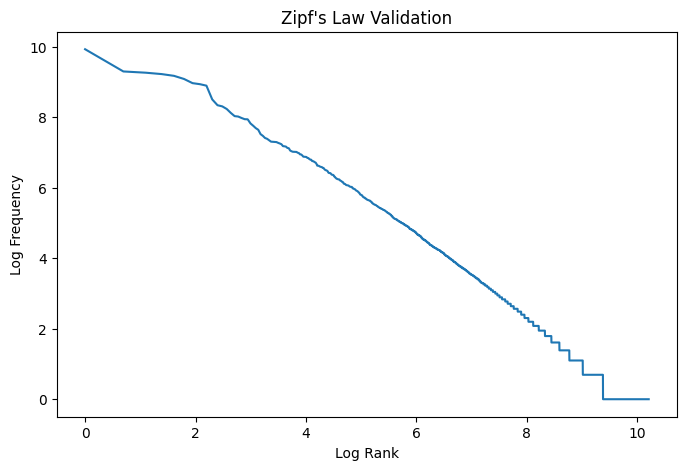

In [43]:
with bz2.open('test.ft.txt.bz2', 'rt', encoding='utf-8') as file:

    for i, line in enumerate(file):

        if i == 5000:
            break

        parts = line.split(' ', 1)

        review = parts[1] if len(parts) > 1 else ""

        reviews.append(review)

    text = " ".join(reviews)

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    word_freq = Counter(words)

    frequencies = sorted(
    word_freq.values(),
    reverse=True
    )

    ranks = np.arange(1, len(frequencies) + 1)

    log_rank = np.log(ranks)
    log_freq = np.log(frequencies)

    plt.figure(figsize=(8,5))

    plt.plot(log_rank, log_freq)

    plt.xlabel("Log Rank")
    plt.ylabel("Log Frequency")
    plt.title("Zipf's Law Validation")

    plt.show()


#### 4. Script a data-quality auditor to quantify the ratio of stop-words to informative tokens across review categories.

In [36]:
import bz2
import nltk
from nltk.corpus import stopwords
import re


In [37]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
stop_words = set(stopwords.words('english'))

In [39]:
positive_stopwords = 0
positive_informative = 0

negative_stopwords = 0
negative_informative = 0

In [40]:
with bz2.open('test.ft.txt.bz2', 'rt', encoding='utf-8') as file:

    for i, line in enumerate(file):

        if i == 1000:
            break

        parts = line.split(' ', 1)

        label = parts[0]
        review = parts[1]

        review = review.lower()
        review = re.sub(r'[^a-zA-Z\s]', '', review)

        words = review.split()

        stop_count = 0

        for word in words:
            if word in stop_words:
                stop_count += 1
            
        info_count = len(words) - stop_count

        if label == '__label__2':   # Positive

            positive_stopwords += stop_count
            positive_informative += info_count

        else:   # Negative

            negative_stopwords += stop_count
            negative_informative += info_count
        
positive_ratio = positive_stopwords / positive_informative
negative_ratio = negative_stopwords / negative_informative

print("Positive Review Ratio:")
print("Stopword / Informative =", positive_ratio)

print("\nNegative Review Ratio:")
print("Stopword / Informative =", negative_ratio)

Positive Review Ratio:
Stopword / Informative = 0.9174243553435684

Negative Review Ratio:
Stopword / Informative = 0.9658070124601564
